# Lecture 2 · Part II — Learning a Ricci-flat Calabi–Yau metric (supervised)

*A geometer's second network.* In Part I a network rediscovered **Euler's formula** from labelled examples. Here we run the **same four-step recipe** on a far harder object: the **Ricci-flat metric** of a Calabi–Yau manifold.

1. **Encode** — represent a point of the manifold, and the metric, as numbers.
2. **Label** — build an *expensive teacher* (Donaldson's algorithm) that outputs ground-truth metrics of increasing accuracy.
3. **Train** — a fast *student* network learns the map (point) $\mapsto$ (metric) by minimising the mean-squared error.
4. **Verify** — an *independent* geometric check, the **$\sigma$-measure**, says how close the learned metric is to Ricci-flat.

Everything is generated in this notebook — no external data. Method after Ashmore, He & Ovrut, *Machine Learning Calabi–Yau Metrics* (arXiv:1910.08605).

## The problem: a metric with no formula

A **Calabi–Yau** manifold is Kähler with vanishing first Chern class. Yau's theorem guarantees a **unique Ricci-flat** Kähler metric in each Kähler class — but gives no formula for it. To this day **no closed-form Ricci-flat metric is known** on any compact Calabi–Yau.

Being Kähler, the metric comes from one real potential $K$,
$$ g_{a\bar b} = \partial_a\partial_{\bar b}K, $$
and Ricci-flatness is the **Monge–Ampère equation**
$$ \omega^3 \;=\; \kappa\,\Omega\wedge\bar\Omega , $$
the Kähler volume form must match the canonical $\Omega\wedge\bar\Omega$ up to one global constant.

Our benchmark is the **Fermat quintic**
$$ Q=\big\{[z_0:\dots:z_4]\in\mathbb{P}^4 \ :\ \textstyle\sum_{i=0}^4 z_i^5 = 0\big\}, $$
a Calabi–Yau threefold. We learn its **metric determinant** $g=\det g_{a\bar b}$ — one real function on $Q$ that already fixes the $\sigma$-measure.

In [1]:
import numpy as np
import torch, torch.nn as nn
import matplotlib.pyplot as plt
from itertools import product
from scipy.special import comb
from scipy.optimize import curve_fit
%matplotlib inline

TEAL, ORANGE, GREY = '#23373B', '#EB811B', '#9AA7AD'
plt.rcParams.update({'figure.dpi':120,'font.size':11,'axes.spines.top':False,
                     'axes.spines.right':False,'axes.grid':True,'grid.alpha':0.25,
                     'axes.edgecolor':'#55666C','figure.facecolor':'white','savefig.facecolor':'white'})
rng = np.random.default_rng(0); torch.manual_seed(0)
print('ready  |  torch', torch.__version__)

ready  |  torch 2.12.1


## Step 1 — Sampling the quintic (and weighting it correctly)

Every integral we need — to *build* the metric and to *measure* it — is an integral over $Q$ against the Calabi–Yau measure $\Omega\wedge\bar\Omega$, approximated by a **Monte-Carlo sum over sample points**.

To get well-distributed points we intersect $Q$ with **random complex lines** in $\mathbb{P}^4$: a line meets the degree-$5$ quintic in exactly $5$ points, and the cloud is close to uniform for the Fubini–Study measure. Each point carries a **weight**
$$ w \;=\; \frac{\Omega\wedge\bar\Omega}{\omega_{\mathrm{FS}}^3} $$
reweighting that cloud to the Calabi–Yau measure. Here $\Omega$ is the holomorphic $3$-form from the residue formula $\Omega = \mathrm{d}u_1\wedge \mathrm{d}u_2\wedge \mathrm{d}u_3 \,/\,(\partial P/\partial u_4)$.

In [2]:
# the Fermat quintic and a line-intersection sampler
def P(z): return np.sum(z**5, axis=-1)                       # defining polynomial

def sample_lines(n_lines, seed=0):
    r = np.random.default_rng(seed)
    a = r.standard_normal((n_lines,5)) + 1j*r.standard_normal((n_lines,5))
    b = r.standard_normal((n_lines,5)) + 1j*r.standard_normal((n_lines,5))
    # P(a + t b) is a degree-5 polynomial in t; its 5 roots are 5 points of Q on the line
    C = np.stack([comb(5,m)*np.sum(a**(5-m)*b**m, axis=1) for m in range(6)], axis=1)
    Z = [a[L] + t*b[L] for L in range(n_lines) for t in np.roots(C[L][::-1])]
    Z = np.array(Z)
    return Z/np.linalg.norm(Z, axis=1, keepdims=True)        # normalise homogeneous coords

# Fubini-Study induced determinant D1 and |Omega|^2 density, per point.
# Patch = coordinate of largest modulus; dependent coord = largest affine coordinate (keeps it stable).
def fs_data(Z):
    M = Z.shape[0]; i0 = np.argmax(np.abs(Z), axis=1)
    u = Z/Z[np.arange(M), i0][:,None]
    D1 = np.zeros(M); Om2 = np.zeros(M)
    for p in range(5):
        m = np.where(i0==p)[0]
        if len(m)==0: continue
        aff = [j for j in range(5) if j!=p]; ua = u[m][:,aff]
        s2 = 1 + np.sum(np.abs(ua)**2, axis=1)
        G = (np.eye(4)[None]*s2[:,None,None] - np.conj(ua)[:,:,None]*ua[:,None,:])/s2[:,None,None]**2
        dl = np.argmax(np.abs(ua), axis=1)
        for dd in range(4):
            s = np.where(dl==dd)[0]
            if len(s)==0: continue
            fr = [a for a in range(4) if a!=dd]; v = ua[s]
            J = -(v[:,fr]**4)/(v[:,[dd]]**4)
            Gf=G[s][:,fr][:,:,fr]; Gfd=G[s][:,fr][:,:,dd]; Gdf=G[s][:,dd][:,fr]; Gdd=G[s][:,dd,dd]
            g = Gf + J[:,:,None]*Gdf[:,None,:] + np.conj(J)[:,None,:]*Gfd[:,:,None] + (J[:,:,None]*np.conj(J)[:,None,:])*Gdd[:,None,None]
            D1[m[s]] = np.real(np.linalg.det(g)); Om2[m[s]] = 1/np.abs(5*v[:,dd]**4)**2
    return D1, Om2

Z = sample_lines(8000, seed=0)          # ~40,000 points on Q
D1, Om2 = fs_data(Z)
weight = Om2/D1                         # Calabi-Yau measure weight
ess = np.sum(weight)**2/np.sum(weight**2)
print(f'{len(Z):,} points on the quintic   |   effective sample size {ess:,.0f} ({100*ess/len(Z):.0f}%)')

40,000 points on the quintic   |   effective sample size 32,988 (82%)


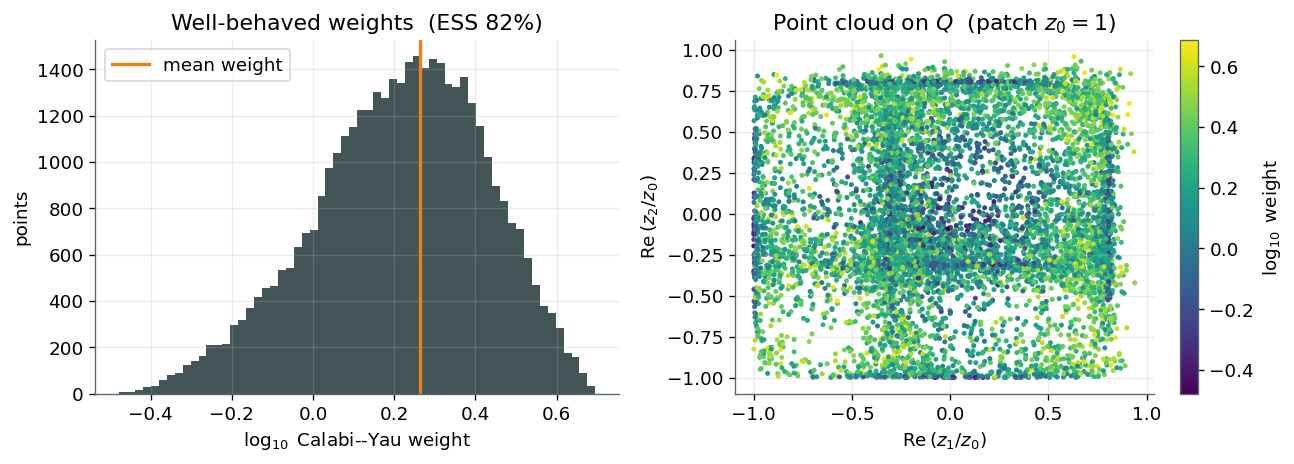

In [3]:
fig, ax = plt.subplots(1, 2, figsize=(11,4))
ax[0].hist(np.log10(weight), bins=60, color=TEAL, alpha=0.85)
ax[0].axvline(np.log10(weight.mean()), color=ORANGE, lw=2, label='mean weight')
ax[0].set(xlabel=r'$\log_{10}$ Calabi--Yau weight', ylabel='points',
          title=f'Well-behaved weights  (ESS {100*ess/len(Z):.0f}%)'); ax[0].legend()

i0 = np.argmax(np.abs(Z), axis=1); sel = np.where(i0==0)[0]
u = Z[sel]/Z[sel,0][:,None]
sc = ax[1].scatter(u[:,1].real, u[:,2].real, c=np.log10(weight[sel]), s=4, cmap='viridis')
ax[1].set(xlabel=r'$\mathrm{Re}\,(z_1/z_0)$', ylabel=r'$\mathrm{Re}\,(z_2/z_0)$',
          title=r'Point cloud on $Q$  (patch $z_0{=}1$)')
plt.colorbar(sc, ax=ax[1], label=r'$\log_{10}$ weight'); plt.tight_layout(); plt.show()

## Step 2 — The expensive teacher: Donaldson's balanced metric

Donaldson's algorithm gives **algebraic** metrics converging to the Ricci-flat one. Fix a degree $k$ and a basis $\{s_\alpha\}$ of degree-$k$ polynomials ($N_k=\binom{k+4}{4}$ of them). Take
$$ K \;=\; \frac{1}{k\pi}\,\log\!\big(s^\dagger H\, s\big), $$
with a Hermitian matrix $H$. The **balanced** $H$ is the fixed point of Donaldson's *T-operator*
$$ T(H) \;=\; N_k\Big\langle \frac{s\,s^\dagger}{\,s^\dagger H s\,}\Big\rangle_{\!Q}, \qquad H \leftarrow T(H)^{-1}, $$
reached in about ten iterations. As $k\to\infty$ the balanced metric $g^{(k)}$ converges to the unique Ricci-flat metric.

The catch is **cost**: $N_k$ and the number of points needed both grow factorially — in the original paper $k{=}12$ takes $\sim 50$ hours and $k{=}20$ would take $\sim 35$ years. We stay small ($k\le 4$): enough to watch it converge, and enough to train a student that leaps ahead.

In [4]:
# degree-k monomials (sections) over the 5 homogeneous coordinates
def exps(k): return np.array([e for e in product(range(k+1),repeat=5) if sum(e)==k], dtype=int)

# Donaldson's T-operator.  Sections at normalised z: the ratio s s^dagger / phi is scale-invariant,
# so no coordinate patch is needed here.
def T_op(Z, w, E, H):
    s = np.prod(Z[:,None,:]**E[None,:,:], axis=2)
    phi = np.real(np.sum(np.conj(s)*(s@H.T), axis=1))
    return np.einsum('n,na,nb->ab', w/phi, s, np.conj(s))*E.shape[0]/np.sum(w)

def balanced_H(Z, w, E, iters=10):
    H = np.eye(E.shape[0], dtype=complex)
    for _ in range(iters):
        H = np.linalg.inv(T_op(Z, w, E, H)); H = 0.5*(H + H.conj().T)
    return H

# determinant of g^(k)_{a b} = d_a d_bbar K, pulled back to Q (patch-robust)
def metric_det(Z, H, E, k):
    M = Z.shape[0]; i0 = np.argmax(np.abs(Z), axis=1); u = Z/Z[np.arange(M),i0][:,None]; D = np.zeros(M)
    for p in range(5):
        m = np.where(i0==p)[0]
        if len(m)==0: continue
        aff=[j for j in range(5) if j!=p]; Ea=E[:,aff]; ua=u[m][:,aff]; mm=len(m); Nk=E.shape[0]
        s = np.prod(ua[:,None,:]**Ea[None,:,:], axis=2)
        ds = np.zeros((mm,4,Nk), complex)
        for i in range(4):
            Ei=Ea.copy(); c=Ea[:,i].copy(); Ei[:,i]-=1
            t=np.prod(ua[:,None,:]**Ei[None,:,:],axis=2)*c[None,:]; t[:,c==0]=0; ds[:,i,:]=t
        hS=s@H.T; phi=np.real(np.sum(np.conj(s)*hS,axis=1)); hds=np.einsum('ab,nib->nia',H,ds)
        dphi=np.stack([np.sum(np.conj(s)*hds[:,i,:],axis=1) for i in range(4)],axis=1)
        Gm=np.zeros((mm,4,4),complex)
        for i in range(4):
            for j in range(4):
                d2=np.sum(np.conj(ds[:,j,:])*hds[:,i,:],axis=1)
                Gm[:,i,j]=(d2/phi - dphi[:,i]*np.conj(dphi[:,j])/phi**2)/(k*np.pi)
        dl=np.argmax(np.abs(ua),axis=1)
        for dd in range(4):
            s2=np.where(dl==dd)[0]
            if len(s2)==0: continue
            fr=[a for a in range(4) if a!=dd]; v=ua[s2]; J=-(v[:,fr]**4)/(v[:,[dd]]**4)
            Gf=Gm[s2][:,fr][:,:,fr]; Gfd=Gm[s2][:,fr][:,:,dd]; Gdf=Gm[s2][:,dd][:,fr]; Gdd=Gm[s2][:,dd,dd]
            g=Gf+J[:,:,None]*Gdf[:,None,:]+np.conj(J)[:,None,:]*Gfd[:,:,None]+(J[:,:,None]*np.conj(J)[:,None,:])*Gdd[:,None,None]
            D[m[s2]]=np.real(np.linalg.det(g))
    return D

# the sigma-measure: weighted average of |1 - (omega^3 / OmegaOmegabar)/mean|; zero iff Ricci-flat
def sigma(D, Om2, w):
    r = D/Om2; ravg = np.sum(w*r)/np.sum(w)
    return np.sum(w*np.abs(1 - r/ravg))/np.sum(w)

KS = [1,2,3,4]; Dets = {}; sig = {}
for k in KS:
    E = exps(k); H = balanced_H(Z, weight, E, iters=10)
    Dets[k] = metric_det(Z, H, E, k); sig[k] = sigma(Dets[k], Om2, weight)
    print(f'k={k}:  N_k={E.shape[0]:2d}   sigma_{k} = {sig[k]:.4f}')

k=1:  N_k= 5   sigma_1 = 0.3706
k=2:  N_k=15   sigma_2 = 0.2707
k=3:  N_k=35   sigma_3 = 0.1927
k=4:  N_k=70   sigma_4 = 0.1319


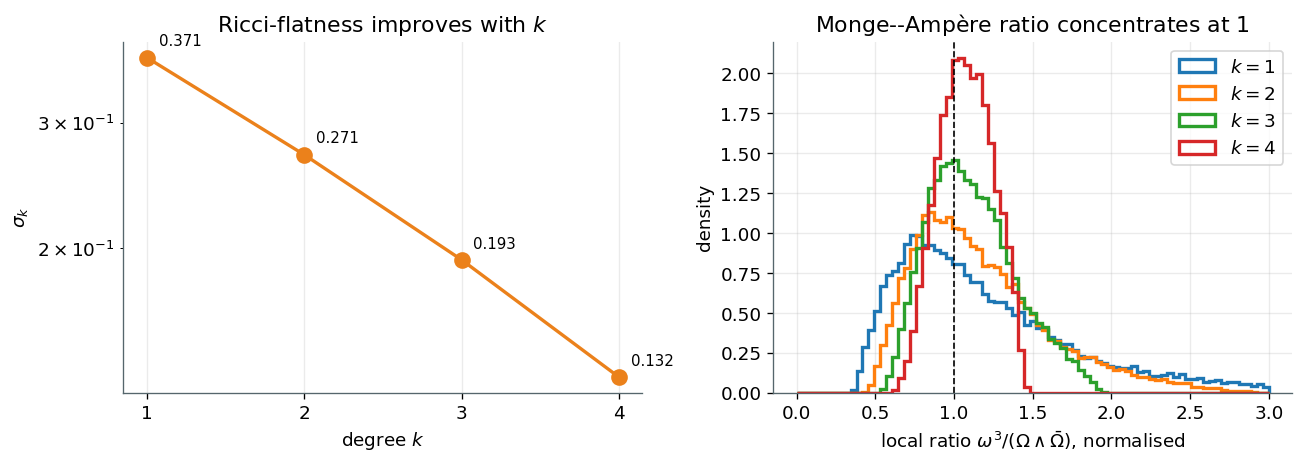

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(11,4))
ks = np.array(KS); sg = np.array([sig[k] for k in KS])
ax[0].plot(ks, sg, 'o-', color=ORANGE, lw=2, ms=9)
for k in KS: ax[0].annotate(f'{sig[k]:.3f}', (k, sig[k]), textcoords='offset points', xytext=(7,7), fontsize=9)
ax[0].set(xlabel='degree $k$', ylabel=r'$\sigma_k$', title=r'Ricci-flatness improves with $k$', xticks=KS)
ax[0].set_yscale('log')

for k in KS:
    r = Dets[k]/Om2; r = r/(np.sum(weight*r)/np.sum(weight))
    ax[1].hist(r, bins=np.linspace(0,3,80), histtype='step', lw=2, density=True, label=f'$k={k}$')
ax[1].axvline(1, color='k', lw=1, ls='--')
ax[1].set(xlabel=r'local ratio $\omega^3/(\Omega\wedge\bar\Omega)$, normalised', ylabel='density',
          title='Monge--Ampère ratio concentrates at $1$'); ax[1].legend()
plt.tight_layout(); plt.show()

## Step 3 — The supervised student

Now the Part I recipe. The metrics $g^{(k)}$ were expensive to build; can a network **predict the best one** from the **cheaper** ones plus the point?

- **Input** — a point $p$, encoded by its (unit-norm, phase-fixed) homogeneous coordinates split into real and imaginary parts (10 numbers), together with the cheap determinants $g^{(1)},g^{(2)},g^{(3)}|_p$. (The paper feeds a network exactly this kind of coordinate-plus-low-degree data.)
- **Target** — the most accurate determinant we computed, $g^{(4)}|_p$.
- **Loss** — mean-squared error on standardised $\log$-determinants.

Just as Euler learned $F$ from $(V,E)$, the network learns $g^{(4)}$ from $\{p,\,g^{(1)},g^{(2)},g^{(3)}\}$ — from only a **small sample**, then predicts everywhere.

In [6]:
# canonical point features: unit norm, phase fixed so the largest coordinate is real positive
def features(Z):
    i0 = np.argmax(np.abs(Z), axis=1)
    ph = Z[np.arange(len(Z)), i0]; ph = ph/np.abs(ph)
    Zc = Z/ph[:,None]                                     # rotate away the U(1) phase
    return np.concatenate([Zc.real, Zc.imag], axis=1)     # 10 real features

def zlog(a):                                             # standardise a log-determinant
    la = np.log(a); return (la-la.mean())/la.std(), la.mean(), la.std()

INP, TGT = [1,2,3], 4                                    # cheap inputs -> expensive target
Xpt = features(Z)
X = np.concatenate([Xpt] + [zlog(Dets[k])[0][:,None] for k in INP], axis=1).astype(np.float32)  # 10+3
ytz, ym, ysd = zlog(Dets[TGT]); y = ytz.astype(np.float32)[:,None]

n = len(Z); idx = rng.permutation(n); ntr = int(0.35*n)   # deliberately small training set
tr, va = idx[:ntr], idx[ntr:]
Xtr,ytr = torch.tensor(X[tr]), torch.tensor(y[tr])
Xva,yva = torch.tensor(X[va]), torch.tensor(y[va])
print(f'train {len(tr):,}   validate {len(va):,}   ({X.shape[1]} inputs: 10 coords + g^(1),g^(2),g^(3))')

train 14,000   validate 26,000   (13 inputs: 10 coords + g^(1),g^(2),g^(3))


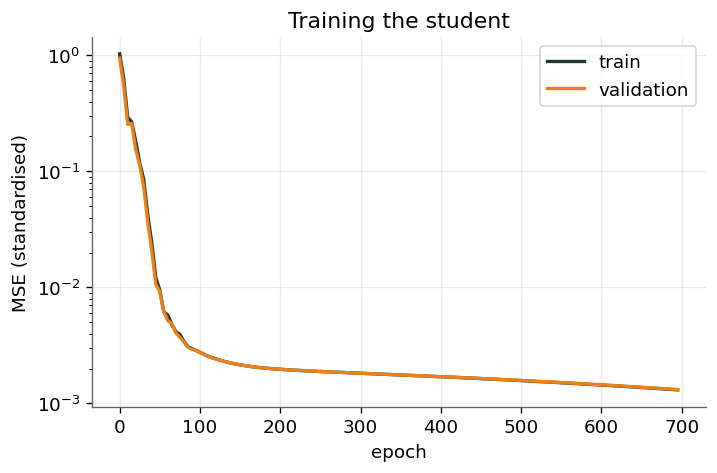

In [7]:
torch.manual_seed(0)
net = nn.Sequential(nn.Linear(X.shape[1],64), nn.SiLU(),
                    nn.Linear(64,64), nn.SiLU(), nn.Linear(64,1))
opt = torch.optim.Adam(net.parameters(), lr=3e-3)
hist = []
for epoch in range(700):
    opt.zero_grad(); L = nn.functional.mse_loss(net(Xtr), ytr); L.backward(); opt.step()
    if epoch % 5 == 0:
        with torch.no_grad(): hist.append((epoch, L.item(), nn.functional.mse_loss(net(Xva), yva).item()))
hist = np.array(hist)
plt.figure(figsize=(6.6,4))
plt.plot(hist[:,0], hist[:,1], color=TEAL, lw=2, label='train')
plt.plot(hist[:,0], hist[:,2], color=ORANGE, lw=2, label='validation')
plt.yscale('log'); plt.xlabel('epoch'); plt.ylabel('MSE (standardised)')
plt.title('Training the student'); plt.legend(); plt.show()

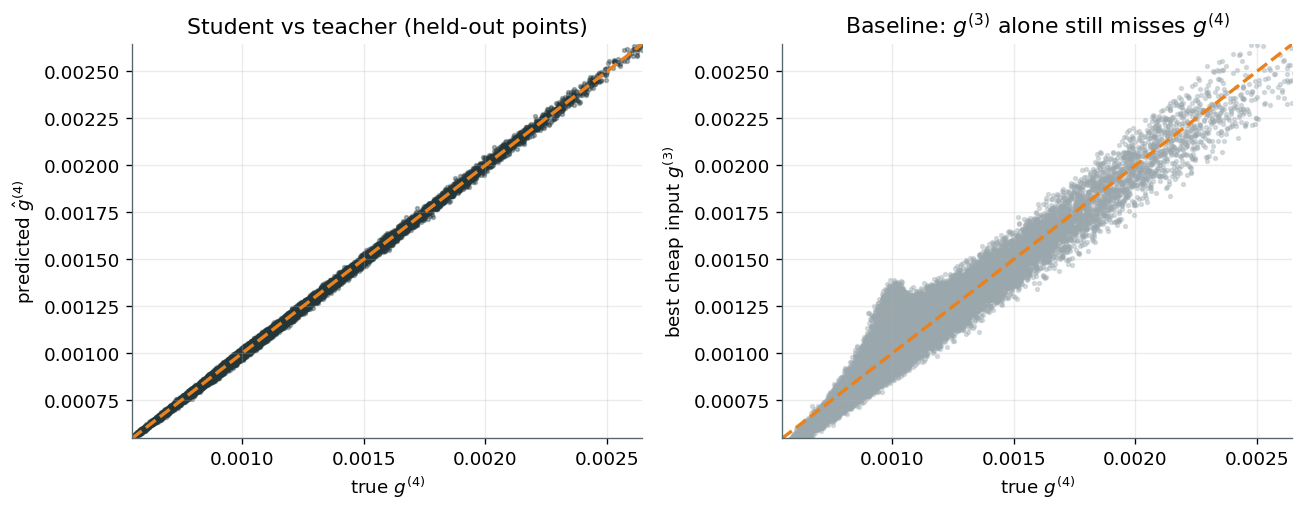

In [11]:
with torch.no_grad(): pred = net(Xva).numpy().ravel()*ysd + ym
g_hat = np.exp(pred)                              # predicted g^(4)
gT, gBest = Dets[TGT][va], Dets[INP[-1]][va]      # teacher target g^(4), best cheap input g^(3)


    
fig, ax = plt.subplots(1, 2, figsize=(11,4.4))
lim = [float(np.percentile(gT,0.3)), float(np.percentile(gT,99.7))]
ax[0].scatter(gT, g_hat, s=5, color=TEAL, alpha=0.35)
ax[0].plot(lim, lim, '--', color=ORANGE, lw=2)
ax[0].set(xlim=lim, ylim=lim, xlabel=r'true $g^{(4)}$', ylabel=r'predicted $\hat g^{(4)}$',
          title='Student vs teacher (held-out points)')
ax[1].scatter(gT, gBest, s=5, color=GREY, alpha=0.35)
ax[1].plot(lim, lim, '--', color=ORANGE, lw=2)
ax[1].set(xlim=lim, ylim=lim, xlabel=r'true $g^{(4)}$', ylabel=r'best cheap input $g^{(3)}$',
          title=r'Baseline: $g^{(3)}$ alone still misses $g^{(4)}$')
import matplotlib.ticker as mticker

for axx in ax:
    axx.xaxis.set_major_locator(mticker.MaxNLocator(5))
    axx.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.4f'))
    
plt.tight_layout(); plt.show()

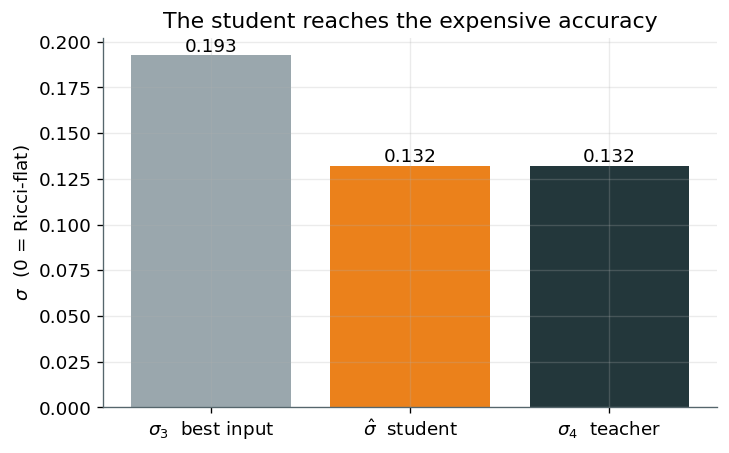

sigma:  best cheap input 0.193  ->  student 0.132   (teacher target 0.132)


In [12]:
# does the learned metric actually get closer to Ricci-flat?  check the sigma-measure on held-out points
wva, Ova = weight[va], Om2[va]
s_in   = sigma(gBest, Ova, wva)      # best cheap input metric g^(3)
s_pred = sigma(g_hat, Ova, wva)      # student prediction of g^(4)
s_true = sigma(gT,    Ova, wva)      # teacher target g^(4)
plt.figure(figsize=(6.6,4))
bars = plt.bar([r'$\sigma_3$  best input', r'$\hat\sigma$  student', r'$\sigma_4$  teacher'],
               [s_in, s_pred, s_true], color=[GREY, ORANGE, TEAL])
for b,v in zip(bars, [s_in,s_pred,s_true]):
    plt.text(b.get_x()+b.get_width()/2, v, f'{v:.3f}', ha='center', va='bottom', fontsize=11)
plt.ylabel(r'$\sigma$  (0 = Ricci-flat)'); plt.title('The student reaches the expensive accuracy'); plt.show()
print(f'sigma:  best cheap input {s_in:.3f}  ->  student {s_pred:.3f}   (teacher target {s_true:.3f})')

## Step 4 — How little data? A learning curve

The paper's striking claim is accuracy *from a small sample*. Let us test it directly: retrain the same network on growing fractions of the data, and watch the held-out $\sigma$ fall toward the teacher's $\sigma_3$.

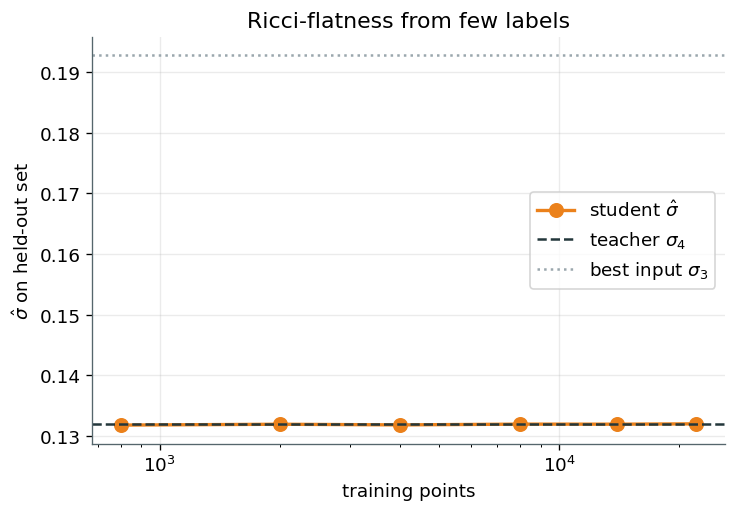

In [13]:
fracs = [0.02, 0.05, 0.10, 0.20, 0.35, 0.55]
base = rng.permutation(n); va_lc = base[int(0.6*n):]; pool = base[:int(0.6*n)]
Xva_lc, yva_lc = torch.tensor(X[va_lc]), torch.tensor(y[va_lc])
counts, val_sig = [], []
for f in fracs:
    tr_lc = pool[:int(f*n)]
    Xt, yt = torch.tensor(X[tr_lc]), torch.tensor(y[tr_lc])
    torch.manual_seed(0)
    m = nn.Sequential(nn.Linear(X.shape[1],64), nn.SiLU(), nn.Linear(64,64), nn.SiLU(), nn.Linear(64,1))
    o = torch.optim.Adam(m.parameters(), lr=3e-3)
    for e in range(500):
        o.zero_grad(); l = nn.functional.mse_loss(m(Xt), yt); l.backward(); o.step()
    with torch.no_grad(): pv = m(Xva_lc).numpy().ravel()*ysd + ym
    counts.append(len(tr_lc)); val_sig.append(sigma(np.exp(pv), Om2[va_lc], weight[va_lc]))

plt.figure(figsize=(6.8,4.4))
plt.plot(counts, val_sig, 'o-', color=ORANGE, lw=2, ms=8, label=r'student $\hat\sigma$')
plt.axhline(sig[4], color=TEAL,  ls='--', label=r'teacher $\sigma_4$')
plt.axhline(sig[3], color=GREY,  ls=':',  label=r'best input $\sigma_3$')
plt.xscale('log'); plt.xlabel('training points'); plt.ylabel(r'$\hat\sigma$ on held-out set')
plt.title('Ricci-flatness from few labels'); plt.legend(); plt.show()

### The paper's shortcut: extrapolate in $k$

Supervised learning still needs the expensive labels. The paper's route to avoid them: at each **fixed point** the determinant relaxes toward its Ricci-flat value like a **decaying exponential**,
$$ g^{(k)}|_p \;\approx\; a_p - b_p\,e^{-c_p k}. $$
Fit it on a few cheap degrees and the constant $a_p$ predicts the $k\to\infty$ value — no high-$k$ computation at all. The relaxation is visible even in our small range (a *reliable* extrapolation uses the cleaner $k=4\ldots7$ regime).

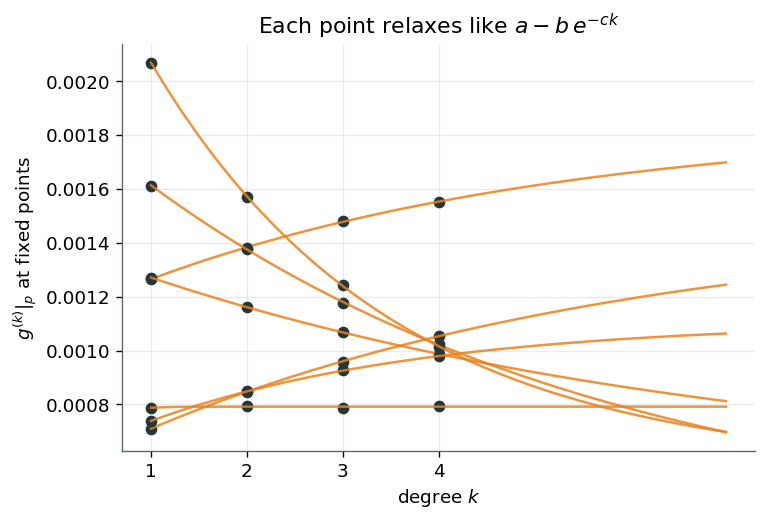

In [14]:
def decay(k, a, b, c): return a - b*np.exp(-c*k)
kk = np.array(KS, float); kg = np.linspace(1, 7, 100)
sel = rng.choice(len(Z), 7, replace=False)
plt.figure(figsize=(6.8,4.4))
for i in sel:
    d = np.array([Dets[k][i] for k in KS])
    plt.plot(kk, d, 'o', color=TEAL, ms=6)
    try:
        p,_ = curve_fit(decay, kk, d, p0=[d[-1], d[-1]-d[0], 1.0],
                        bounds=([-1e3,-1e3,0.05],[1e3,1e3,5.0]), maxfev=5000)
        plt.plot(kg, decay(kg,*p), color=ORANGE, lw=1.5, alpha=0.85)
    except Exception:
        pass
plt.xlabel('degree $k$'); plt.ylabel(r'$g^{(k)}|_p$ at fixed points'); plt.xticks(KS)
plt.title(r'Each point relaxes like $a-b\,e^{-ck}$'); plt.show()

## Recap — and the road on

We ran the Part I recipe on a Ricci-flat metric:

- **Encode** a point and the metric determinant as numbers.
- **Label** with Donaldson's expensive balanced metrics — $\sigma_k$ falling as $k$ grows.
- **Train** a small network, by MSE, to predict the expensive determinant from cheaper ones and the point.
- **Verify** with the $\sigma$-measure: the student's $\hat\sigma$ matches the teacher's, from a fraction of the labels.

The one limitation is that we needed a teacher to make labels. The frontier method removes it — **cymetric** builds the loss *directly from the geometric equations* (Monge–Ampère, Kähler, transition, Ricci), with **no labels at all**. That self-supervised idea is exactly what powers the $\mathrm{G}_2$ construction in Topic III, and the neural PDEs of Lecture 3.